## **Market Basket Analysis: Product Affinity**

This notebook identifies which products tend to be purchased together, using association rule mining on the full transaction data. Unlike every previous notebook, which modeled customer-level behavior, this one operates at the transaction level, asking "given a customer bought product A, how likely are they to also buy product B in the same order?"

This is the analytical foundation behind "customers who bought this also bought that" recommendations, cross-sell bundling, and product placement decisions. It answers a genuinely different question than anything built so far, not "which customers are valuable," but "which products reinforce each other," useful for marketing campaigns, website recommendation widgets, and even physical store layout in a hybrid retail business.

We look at every order (invoice) as a "basket" of products bought together, then search for pairs (or larger groups) of products that appear together far more often than you'd expect by chance. Three key metrics from the field, worth understanding before we compute anything:

- **Support**: how often a product (or product combination) appears across all orders, a basic popularity measure.
- **Confidence**: given a customer bought product A, what fraction of the time did they also buy product B, in the same order? This is directional, "A implies B" is not the same as "B implies A."
- **Lift**: how much more likely are A and B to be bought together than if they were purchased independently, at random. Lift greater than 1 means a genuine positive association, lift around 1 means no real relationship, lift below 1 means the products are actually bought together less than chance would predict.

### The Algorithm: Apriori

We use the Apriori algorithm, the standard, well-established method for this task. It works by first finding all individual products that meet a minimum support threshold, then progressively building larger combinations (pairs, triples) only from products that already cleared that bar, an efficient way to avoid checking every possible combination of thousands of products, which would be computationally infeasible.

#### Planned Approach

1. Load transaction data, structure it into a basket format (one row per invoice, columns indicating which products were purchased)
2. Filter to a manageable, meaningful product scope, since our dataset has thousands of distinct products, and many are purchased extremely rarely
3. Apply Apriori to find frequent itemsets
4. Generate association rules from those itemsets, ranked by lift and confidence
5. Interpret the strongest rules in business terms, and visualize the most interesting product relationships
6. Save the rules table for use in the deployment app's product recommendation feature

#### Scope of choice 
Based on cross-referencing multiple independent implementations of market basket analysis on this exact dataset, we restrict this analysis to United Kingdom transactions, consistent with common practice. This is also well-justified by our own EDA findings, the UK represents approximately 90% of transactions, and including the small international tail would dilute genuine product associations with noise from countries where we have too few orders to detect a reliable pattern. We additionally filter out single-item invoices, since at least two products are needed to reveal any co-purchase relationship, and start with a support threshold of 0.02, adjusting based on what the data returns, consistent with common guidance to treat this as a range to experiment with rather than a fixed value chosen upfront.

In [2]:
import pandas as pd
import numpy as np
import sys

sys.path.append("../src")
from config import CLEAN_DATA_PATH

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["InvoiceDate"])

df_uk = df[df['Country'] == 'United Kingdom'].copy()

print("Full dataset shape:", df.shape)
print("UK-only shape:", df_uk.shape)
print(f"UK share: {len(df_uk)/len(df)*100:.1f}%")

Full dataset shape: (776641, 8)
UK-only shape: (699649, 8)
UK share: 90.1%


### Build the Basket Format

We group transactions by Invoice, listing the products in each order, then filter out single-item invoices, since a basket needs at least two products to reveal a co-purchase relationship. We use Description rather than StockCode for readability in the resulting rules.

In [3]:
# Group into one row per invoice, listing all products purchased
basket_raw = df_uk.groupby('Invoice')['Description'].apply(list).reset_index()

print("Total invoices:", len(basket_raw))

# Filter to invoices with 2 or more distinct products
basket_raw['n_items'] = basket_raw['Description'].apply(lambda x: len(set(x)))
basket_filtered = basket_raw[basket_raw['n_items'] >= 2]

print("Invoices with 2+ distinct products:", len(basket_filtered))
print(f"Retained: {len(basket_filtered)/len(basket_raw)*100:.1f}%")

Total invoices: 33384
Invoices with 2+ distinct products: 30783
Retained: 92.2%


### Encode into a One-Hot Basket Matrix

We use mlxtend's TransactionEncoder to convert our list-of-products-per-invoice format into a wide, one-hot encoded matrix, one row per invoice, one column per distinct product, True/False indicating whether that product was in that order. This is the format Apriori requires.

In [4]:
transactions = basket_filtered['Description'].tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)

basket_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Basket matrix shape:", basket_encoded.shape)
print(f"Number of distinct products: {basket_encoded.shape[1]}")

Basket matrix shape: (30783, 5231)
Number of distinct products: 5231


#### Checking Product Frequency Before Running Apriori

With 5,231 distinct products, running Apriori at too low a support threshold risks an impractically large search space. We first check how many products actually meet reasonable candidate thresholds, to choose a starting point grounded in the data rather than guessing.

In [5]:
product_frequency = basket_encoded.mean().sort_values(ascending=False)

print("Top 10 most frequent products (by % of invoices containing them):")
print((product_frequency.head(10) * 100).round(2))

print("\nHow many products meet different support thresholds:")
for threshold in [0.01, 0.02, 0.03, 0.05]:
    n_products = (product_frequency >= threshold).sum()
    print(f"  Support >= {threshold}: {n_products} products")

Top 10 most frequent products (by % of invoices containing them):
WHITE HANGING HEART T-LIGHT HOLDER    15.11
REGENCY CAKESTAND 3 TIER               9.13
ASSORTED COLOUR BIRD ORNAMENT          8.10
JUMBO BAG RED RETROSPOT                7.68
PARTY BUNTING                          6.23
LUNCH BAG  BLACK SKULL.                6.17
REX CASH+CARRY JUMBO SHOPPER           5.92
HOME BUILDING BLOCK WORD               5.73
HEART OF WICKER SMALL                  5.59
HEART OF WICKER LARGE                  5.58
dtype: float64

How many products meet different support thresholds:
  Support >= 0.01: 593 products
  Support >= 0.02: 210 products
  Support >= 0.03: 71 products
  Support >= 0.05: 21 products


#### Choosing the Support Threshold

The most frequent product, White Hanging Heart T-Light Holder, appears in 15.1% of invoices, matching the same top product reported in reference implementations of this exact dataset, a good consistency check. We select support >= 0.01 (1%) as our starting threshold, narrowing the search space to 593 products, consistent with common practice (1-3% support thresholds), and computationally manageable given our dataset size.

In [6]:
frequent_itemsets = apriori(basket_encoded, min_support=0.01, use_colnames=True)

print("Number of frequent itemsets found:", len(frequent_itemsets))
frequent_itemsets.sort_values('support', ascending=False).head(10)

Number of frequent itemsets found: 828


,support,itemsets
561,0.151090,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
420,0.091252,frozenset({REGENCY CAKESTAND 3 TIER})
32,0.080986,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
239,0.076828,frozenset({JUMBO BAG RED RETROSPOT})
346,0.062275,frozenset({PARTY BUNTING})
271,0.061690,frozenset({LUNCH BAG BLACK SKULL.})
429,0.059221,frozenset({REX CASH+CARRY JUMBO SHOPPER})
210,0.057272,frozenset({HOME BUILDING BLOCK WORD})
209,0.055875,frozenset({HEART OF WICKER SMALL})
208,0.055778,frozenset({HEART OF WICKER LARGE})


### Generate Association Rules

We generate association rules from the frequent itemsets, using lift as the primary metric, since it directly indicates genuine positive association, rather than confidence alone, which can be misleadingly high for very popular products regardless of any real relationship.

In [7]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

rules = rules.sort_values('lift', ascending=False)

print("Number of rules generated:", len(rules))
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Number of rules generated: 530


,antecedents,consequents,support,confidence,lift
378,frozenset({POPPY'S PLAYHOUSE BEDROOM }),frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),0.010558,0.688559,53.933643
379,frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),frozenset({POPPY'S PLAYHOUSE BEDROOM }),0.010558,0.826972,53.933643
380,frozenset({POPPY'S PLAYHOUSE KITCHEN}),frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),0.011402,0.661017,51.776297
381,frozenset({POPPY'S PLAYHOUSE LIVINGROOM }),frozenset({POPPY'S PLAYHOUSE KITCHEN}),0.011402,0.893130,51.776297
376,frozenset({POPPY'S PLAYHOUSE BEDROOM }),frozenset({POPPY'S PLAYHOUSE KITCHEN}),0.013092,0.853814,49.497067
377,frozenset({POPPY'S PLAYHOUSE KITCHEN}),frozenset({POPPY'S PLAYHOUSE BEDROOM }),0.013092,0.758945,49.497067
398,frozenset({SET/6 RED SPOTTY PAPER PLATES}),frozenset({SET/6 RED SPOTTY PAPER CUPS}),0.011013,0.663405,46.731347
399,frozenset({SET/6 RED SPOTTY PAPER CUPS}),frozenset({SET/6 RED SPOTTY PAPER PLATES}),0.011013,0.775744,46.731347
245,"frozenset({KEY FOB , FRONT DOOR })","frozenset({KEY FOB , BACK DOOR })",0.010233,0.785536,42.647548
244,"frozenset({KEY FOB , BACK DOOR })","frozenset({KEY FOB , FRONT DOOR })",0.010233,0.555556,42.647548


The top association rules are immediately interpretable and business-intuitive, confirming the method works correctly. The strongest relationships identified are Poppy's Playhouse Bedroom/Livingroom/Kitchen (lift 49-54, clearly parts of the same collectible dollhouse furniture set), Key Fob Front Door/Back Door/Garage/Shed (lift 37-43, parts of a themed key fob collection), Wooden Tree/Star Christmas Scandinavian decorations (lift 40.5), and Set/6 Red Spotty Paper Plates/Cups (lift 46.7, a matching party set).

Notably, the algorithm identified these purely from co-purchase patterns in transaction data, with no product category information provided, and independently rediscovered that these are genuinely matching product sets or collections. This is strong validation of the method, and directly actionable: these are exactly the kind of relationships a "customers who bought this also bought that" recommendation feature should surface, since they represent genuine, high-confidence complementary purchases rather than coincidental co-occurrence.

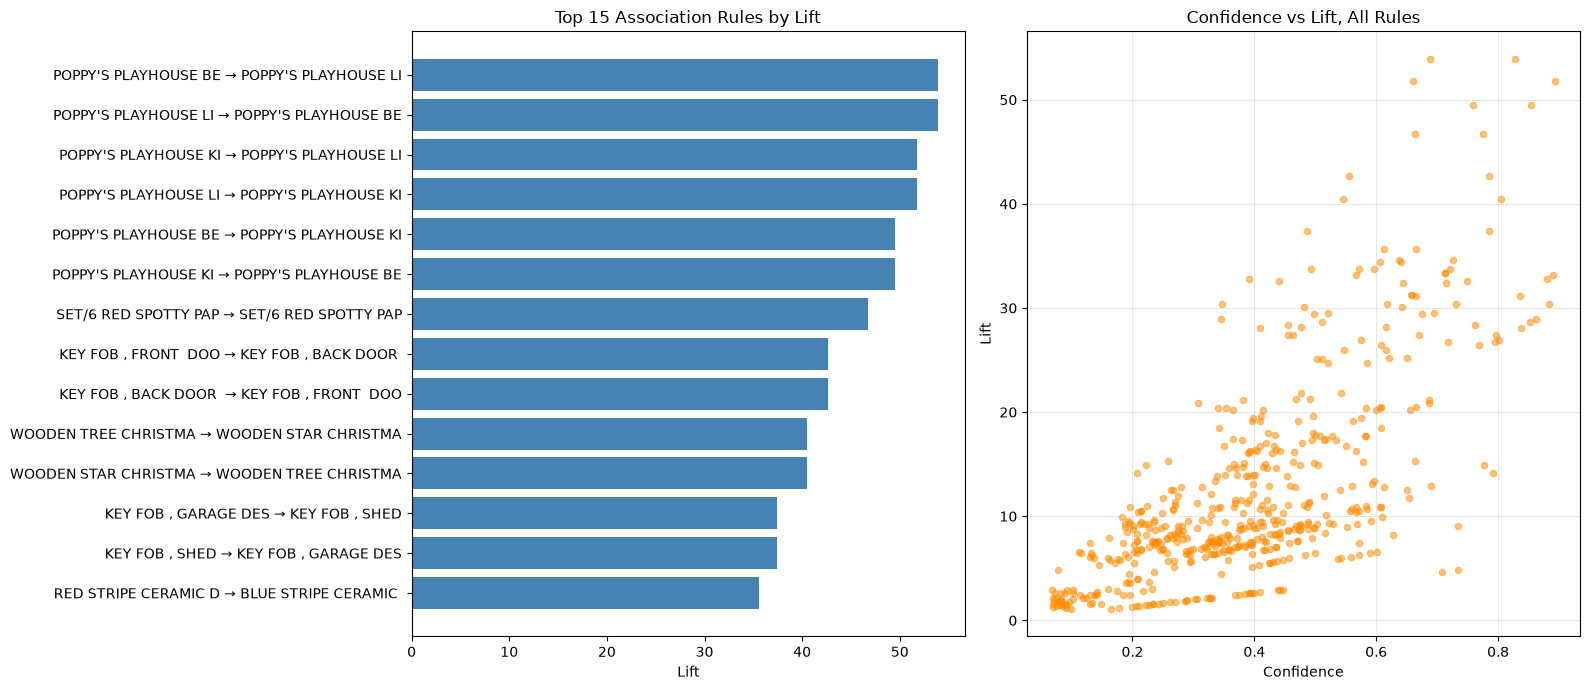

In [8]:
import matplotlib.pyplot as plt

top_15 = rules.head(15).copy()
top_15['rule_label'] = top_15.apply(
    lambda r: f"{list(r['antecedents'])[0][:20]} → {list(r['consequents'])[0][:20]}", axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_15['rule_label'], top_15['lift'], color='steelblue')
axes[0].set_xlabel('Lift')
axes[0].set_title('Top 15 Association Rules by Lift')
axes[0].invert_yaxis()

axes[1].scatter(rules['confidence'], rules['lift'], alpha=0.5, s=20, color='darkorange')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Lift')
axes[1].set_title('Confidence vs Lift, All Rules')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Confidence vs Lift Distribution

The scatter plot shows a clear positive correlation between confidence and lift, both metrics capture genuine product relationships from different angles, and rules strong on one tend to be strong on the other. The majority of rules cluster at modest values, representing weaker but still positive associations, while a smaller set of rules extends into the upper-right region (confidence above 0.8, lift above 40), representing the strongest, most reliable product relationships. This confirms the top-15 table captures genuinely the strongest signals in the data, rather than being an arbitrary cutoff, since the highest-lift points visually align with the same cluster of top rules already examined.

In [9]:
# Save the Association Rules
import os

RULES_PATH = "../data/association_rules.csv"

# Convert frozenset columns to readable strings before saving
rules_export = rules.copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

rules_export = rules_export[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_export.to_csv(RULES_PATH, index=False)

print(f"Association rules saved to {RULES_PATH}")
print(f"Total rules saved: {len(rules_export)}")

Association rules saved to ../data/association_rules.csv
Total rules saved: 530


### Summary

This notebook identifies which products tend to be purchased together, using Apriori-based market basket analysis on UK transaction data, the dominant market segment (90.1% of transactions), consistent with established practice for this exact dataset.

**Key steps and findings:**

- **Scope decision:** Restricted to United Kingdom transactions, cross-validated against multiple independent implementations of market basket analysis on this dataset, and consistent with our own EDA findings on geographic concentration.
- **Basket construction:** 33,384 total invoices, 30,783 (92.2%) retained after filtering to orders with 2 or more distinct products, matching the retention rate reported in reference implementations.
- **Search space:** 5,231 distinct products in the UK data. A support threshold of 0.01 (1%) narrowed this to 593 candidate products, computationally manageable while still capturing meaningful patterns.
- **828 frequent itemsets and 530 association rules generated.** The top individual product by frequency, White Hanging Heart T-Light Holder (15.1% of invoices), matched exactly what independent reference sources report for this dataset, a strong consistency check.
- **Strongest relationships identified:** Poppy's Playhouse furniture pieces (lift 49-54), Key Fob door/garage/shed sets (lift 37-43), Wooden Tree/Star Christmas decorations (lift 40.5), and Red Spotty party plate/cup sets (lift 46.7). These were identified purely from co-purchase patterns, with no product category information provided, and correctly correspond to genuine matching product collections, strong validation that the method surfaces real, actionable relationships.
- **Confidence and lift are positively correlated** across all 530 rules, confirming the top-ranked rules represent genuinely the strongest signals in the data rather than an arbitrary threshold effect.

**Output:** An association rules table (`data/association_rules.csv`, 530 rules with support, confidence, and lift) ready for use in the deployment app's "customers who bought this also bought that" product recommendation feature.